<a href="https://colab.research.google.com/github/kaifkh20/d2l/blob/main/d2l_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install d2l --no-deps

In [3]:
%matplotlib inline
import time
import torch
import torchvision
from torchvision import transforms
from d2l import torch as d2l
from torch import nn
from torch.nn import functional as F

d2l.use_svg_display()


In [4]:
class FashionMNIST(d2l.DataModule):
    """The Fashion-MNIST dataset."""
    def __init__(self, batch_size=64, resize=(28, 28)):
        super().__init__()
        self.save_hyperparameters()
        trans = transforms.Compose([transforms.Resize(resize),
                                    transforms.ToTensor()])
        self.train = torchvision.datasets.FashionMNIST(
            root=self.root, train=True, transform=trans, download=True)
        self.val = torchvision.datasets.FashionMNIST(
            root=self.root, train=False, transform=trans, download=True)


This turns number labels to appropiate text labels

In [5]:
@d2l.add_to_class(FashionMNIST)
def text_labels(self, indices):
    """Return text labels."""
    labels = ['t-shirt', 'trouser', 'pullover', 'dress', 'coat',
              'sandal', 'shirt', 'sneaker', 'bag', 'ankle boot']
    return [labels[int(i)] for i in indices]

@d2l.add_to_class(FashionMNIST)
def get_dataloader(self, train):
    data = self.train if train else self.val
    return torch.utils.data.DataLoader(data, self.batch_size, shuffle=train,
                                       num_workers=self.num_workers)


Every

In [7]:
data = FashionMNIST(batch_size=64,resize=(32,32))

In [ ]:
X, y = next(iter(data.train_dataloader()))
print(X.shape, X.dtype, y.shape, y.dtype) # (batch_size,color_channels,height,width)


torch.Size([64, 1, 32, 32]) torch.float32 torch.Size([64]) torch.int64


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


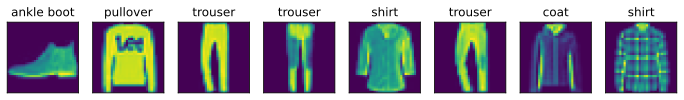

In [8]:
@d2l.add_to_class(FashionMNIST)
def visualize(self, batch, nrows=1, ncols=8, labels=[]): #nrows and cols is how many to display
    X, y = batch
    if not labels:
        labels = self.text_labels(y)
    #squeeze change to (batch_size, 28, 28) {this is how show image expects it}
    d2l.show_images(X.squeeze(1), nrows, ncols, titles=labels)
batch = next(iter(data.val_dataloader()))
data.visualize(batch)

Now follows the SoftMax classfication from some-off scratch

In [ ]:
class SoftmaxRegressionScratch(d2l.Classifier):
    def __init__(self, num_inputs, num_outputs, lr, sigma=0.01):
        super().__init__()
        self.save_hyperparameters()
        self.W = torch.normal(0, sigma, size=(num_inputs, num_outputs),
                              requires_grad=True)
        self.b = torch.zeros(num_outputs, requires_grad=True)

    def parameters(self):
        return [self.W, self.b]


In [ ]:
def softmax(X):
  X_ep = torch.exp(X)
  partition = X_ep.sum(1, keepdim=True)
  return X_ep / partition

@d2l.add_to_class(SoftmaxRegressionScratch)
def forward(self, X):
    X = X.reshape((-1, self.W.shape[0])) #reshape is to make (64,1,28,28) -> (64,1*28*28) so each neuron gets 64*(28*28) as input
    return softmax(torch.matmul(X, self.W) + self.b)

@d2l.add_to_class(SoftmaxRegressionScratch)
def forward(self, X):
    X = X.reshape((-1, self.W.shape[0]))
    return softmax(torch.matmul(X, self.W) + self.b)

def cross_entropy(y_hat, y):
    return -torch.log(y_hat[list(range(len(y_hat))), y]).mean()  #log(y_hat[y^(true_label),y(true_label)]).mean()




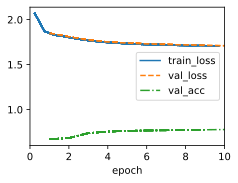

In [ ]:
data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegressionScratch(num_inputs=784, num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)

In [60]:
X, y = next(iter(data.val_dataloader()))
preds = model(X).argmax(axis=1)
preds.shape

torch.Size([64])

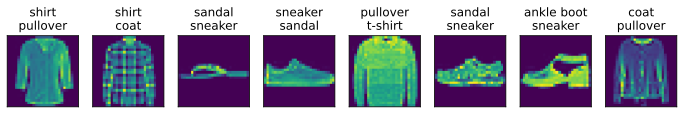

In [ ]:
#gets only those which were classified wrong

wrong = preds.type(y.dtype) != y
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [a+'\n'+b for a, b in zip(
    data.text_labels(y), data.text_labels(preds))]
data.visualize([X, y], labels=labels)


Now follows the concise implementation

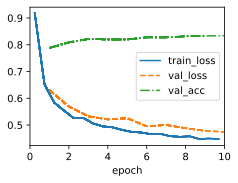

In [ ]:
class SoftmaxRegression(d2l.Classifier):
    """The softmax regression model."""
    def __init__(self, num_outputs, lr):
        super().__init__()
        self.save_hyperparameters()
        self.net = nn.Sequential(nn.Flatten(),
                                 nn.LazyLinear(num_outputs))

    def forward(self, X):
        return self.net(X)

data = d2l.FashionMNIST(batch_size=256)
model = SoftmaxRegression(num_outputs=10, lr=0.1)
trainer = d2l.Trainer(max_epochs=10)
trainer.fit(model, data)


In [9]:
class SoftmaxRegressionPyTorch(nn.Module):
    def __init__(self, num_inputs, num_outputs, lr=0.01):
        super().__init__()
        self.lr = lr
        self.net = nn.Sequential(nn.Flatten(), nn.Linear(num_inputs, num_outputs))

    def forward(self, X):
        return self.net(X)

    def parameters(self):
        return self.net.parameters()

    def loss(self, y_hat, y):
        return F.cross_entropy(y_hat, y)

    def accuracy(self, y_hat, y):
        return (y_hat.argmax(dim=1) == y).float().mean()

    def __call__(self, X):
        return self.forward(X)

    def get_optimizer(self):
        return torch.optim.SGD(self.parameters(), lr=self.lr)

In [13]:
data = d2l.FashionMNIST(batch_size=256)

model = SoftmaxRegressionPyTorch(num_inputs=784, num_outputs=10, lr=0.1)
loss_fn = model.loss
optimizer = model.get_optimizer()
accuracy_fn = model.accuracy

train_dataloader = data.train_dataloader()
val_dataloader = data.val_dataloader()

# Training loop
num_epochs = 10
for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss, train_accuracy, train_batches = 0, 0, 0
    for X, y in train_dataloader:
        y_hat = model(X)
        l = loss_fn(y_hat, y)
        optimizer.zero_grad()
        l.backward()
        optimizer.step()

        # Track training metrics
        train_loss += l.item()
        train_accuracy += accuracy_fn(y_hat, y).item()
        train_batches += 1

    # Evaluation on validation set
    model.eval()
    val_loss, val_accuracy, val_batches = 0, 0, 0
    with torch.no_grad():
        for X, y in val_dataloader:
            y_hat = model(X)
            val_loss += loss_fn(y_hat, y).item()
            val_accuracy += accuracy_fn(y_hat, y).item()
            val_batches += 1

    # Calculate averages
    avg_train_loss = train_loss / train_batches
    avg_train_accuracy = train_accuracy / train_batches
    avg_val_loss = val_loss / val_batches
    avg_val_accuracy = val_accuracy / val_batches

    print(f'Epoch [{epoch+1}/{num_epochs}], Train Loss: {avg_train_loss:.4f}, Train Accuracy: {avg_train_accuracy:.4f}, Val Loss: {avg_val_loss:.4f}, Val Accuracy: {avg_val_accuracy:.4f}')

/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


Epoch [1/10], Train Loss: 0.7841, Train Accuracy: 0.7492, Val Loss: 0.6662, Val Accuracy: 0.7633
Epoch [2/10], Train Loss: 0.5704, Train Accuracy: 0.8124, Val Loss: 0.6002, Val Accuracy: 0.7847
Epoch [3/10], Train Loss: 0.5262, Train Accuracy: 0.8243, Val Loss: 0.5329, Val Accuracy: 0.8174
Epoch [4/10], Train Loss: 0.5024, Train Accuracy: 0.8314, Val Loss: 0.5483, Val Accuracy: 0.8022
Epoch [5/10], Train Loss: 0.4862, Train Accuracy: 0.8357, Val Loss: 0.5472, Val Accuracy: 0.8040
Epoch [6/10], Train Loss: 0.4736, Train Accuracy: 0.8405, Val Loss: 0.5117, Val Accuracy: 0.8239
Epoch [7/10], Train Loss: 0.4655, Train Accuracy: 0.8436, Val Loss: 0.4866, Val Accuracy: 0.8330
Epoch [8/10], Train Loss: 0.4581, Train Accuracy: 0.8445, Val Loss: 0.4892, Val Accuracy: 0.8281
Epoch [9/10], Train Loss: 0.4524, Train Accuracy: 0.8468, Val Loss: 0.4823, Val Accuracy: 0.8306
Epoch [10/10], Train Loss: 0.4475, Train Accuracy: 0.8479, Val Loss: 0.4742, Val Accuracy: 0.8345


/usr/local/lib/python3.11/dist-packages/torch/utils/data/dataloader.py:624: UserWarning: This DataLoader will create 4 worker processes in total. Our suggested max number of worker in current system is 2, which is smaller than what this DataLoader is going to create. Please be aware that excessive worker creation might get DataLoader running slow or even freeze, lower the worker number to avoid potential slowness/freeze if necessary.
  warnings.warn(


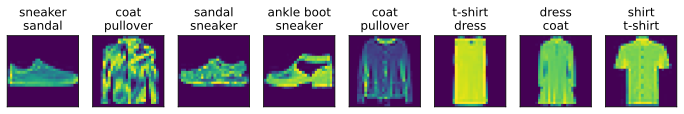

In [15]:
#gets only those which were classified wrong
X,y = next(iter(data.val_dataloader()))
preds = model(X).argmax(axis=1)

wrong = preds.type(y.dtype) != y
X, y, preds = X[wrong], y[wrong], preds[wrong]
labels = [a+'\n'+b for a, b in zip(
    data.text_labels(y), data.text_labels(preds))]
data.visualize([X, y], labels=labels)


# for X,y in data.val_dataloader():
#     # X, y = next(iter(data.val_dataloader()))
#     preds = model(X).argmax(axis=1) #get for each row
#     labels = [a+'\n'+b for a, b in zip(
#         data.text_labels(y), data.text_labels(preds))]
#     data.visualize([X, y], labels=labels)